In [1]:
# === Run this cell FIRST (works even if the notebook is inside /Model) ===
import os, sys, pathlib

# Add the project root (the folder that contains `project_package/`) to Python path
def add_project_root(marker_folder="project_package", max_up=5):
    cur = pathlib.Path(".").resolve()
    for _ in range(max_up + 1):
        if (cur / marker_folder).is_dir():
            if str(cur) not in sys.path:
                sys.path.insert(0, str(cur))
            return cur
        cur = cur.parent
    raise RuntimeError(f"Could not find '{marker_folder}' up to {max_up} levels above.")

PROJECT_ROOT = add_project_root()
print("PROJECT_ROOT =", PROJECT_ROOT)

# Resolve CSV location (here we assume it's at the project root; move to /datasets if you prefer)
CSV_NAME = "ncr_ride_bookings_with_weather_filled_scaled_short.csv"
csv_path = PROJECT_ROOT / CSV_NAME
print("CSV exists:", csv_path.exists(), "->", csv_path)

# Import unsupervised runners from your package
from project_package.modeling import (
    run_kmeans_from_csv,
    run_isolation_forest_from_csv,
    run_pca_embeddings_from_csv,
)

# ID columns to carry through outputs (useful for later joins/plots)
IDS = ["Booking ID", "Customer ID"]

# --- 1) KMeans clustering ---
# Tries multiple k, picks the best by silhouette; exports labels and PCA(2D) CSVs.
km = run_kmeans_from_csv(
    csv_path=str(csv_path),
    id_cols=IDS,
    artifacts_dir="unsupervised",   # will be saved under <project_root>/artifacts/unsupervised/
    k_list=[3, 5, 8, 10],
    random_state=42,
)
print("Best k:", km.best_k)
print("Quality per k:", km.report)
print("Labels CSV:", km.labels_csv_path)
print("PCA(2D) CSV:", km.pca2_csv_path)

# --- 2) Isolation Forest (anomaly detection) ---
# Flags unusual rows; contamination ≈ expected outlier fraction.
iso = run_isolation_forest_from_csv(
    csv_path=str(csv_path),
    id_cols=IDS,
    artifacts_dir="unsupervised",
    contamination=0.02,
    random_state=42,
)
print("Anomaly scores CSV:", iso.scores_csv_path)

# --- 3) PCA embeddings (2D) ---
# Produces 2D coordinates (pc1, pc2) for easy scatter plotting.
emb = run_pca_embeddings_from_csv(
    csv_path=str(csv_path),
    id_cols=IDS,
    artifacts_dir="unsupervised",
    n_components=2,
    random_state=42,
)
print("PCA embeddings CSV:", emb.embed_csv_path)


PROJECT_ROOT = /Users/makabaka/Documents/GitHub/MADS-MS2-Uber-Analysis
CSV exists: True -> /Users/makabaka/Documents/GitHub/MADS-MS2-Uber-Analysis/ncr_ride_bookings_with_weather_filled_scaled_short.csv
Best k: 5
Quality per k: {3: {'silhouette': 0.35546941295015305, 'dbi': 0.9052378837460658, 'ch': 104492.29810742913}, 5: {'silhouette': 0.35655068727132627, 'dbi': 0.9159452513668309, 'ch': 120780.94401266333}, 8: {'silhouette': 0.31599906638856795, 'dbi': 0.9038054921448941, 'ch': 118250.4249843495}, 10: {'silhouette': 0.31100158385381776, 'dbi': 0.9473177744164459, 'ch': 113979.6711039582}}
Labels CSV: /Users/makabaka/Documents/GitHub/MADS-MS2-Uber-Analysis/unsupervised/kmeans_k5_labels.csv
PCA(2D) CSV: /Users/makabaka/Documents/GitHub/MADS-MS2-Uber-Analysis/unsupervised/kmeans_k5_pca2.csv
Anomaly scores CSV: /Users/makabaka/Documents/GitHub/MADS-MS2-Uber-Analysis/unsupervised/isoforest_scores.csv
PCA embeddings CSV: /Users/makabaka/Documents/GitHub/MADS-MS2-Uber-Analysis/unsupervised

Show Model Result in a Table and Graph

In [3]:
results = km.report

    k  silhouette       dbi             ch
0   3    0.355469  0.905238  104492.298107
1   5    0.356551  0.915945  120780.944013
2   8    0.315999  0.903805  118250.424984
3  10    0.311002  0.947318  113979.671104


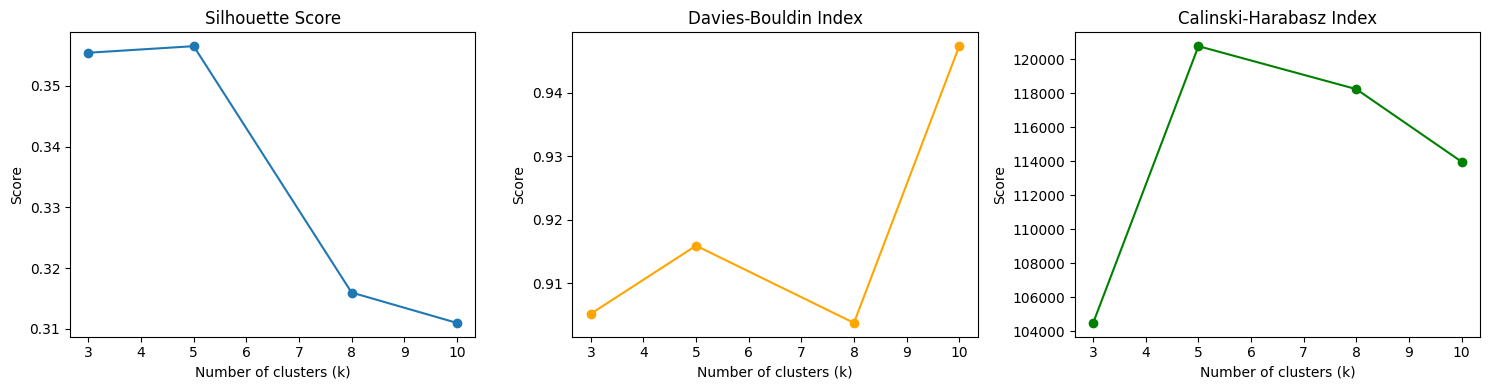

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert to DataFrame
df_results = pd.DataFrame(results).T.reset_index()
df_results.rename(columns={'index': 'k'}, inplace=True)

# Show table
print(df_results)

# Plot metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df_results['k'], df_results['silhouette'], marker='o')
axes[0].set_title("Silhouette Score")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Score")

axes[1].plot(df_results['k'], df_results['dbi'], marker='o', color='orange')
axes[1].set_title("Davies-Bouldin Index")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Score")

axes[2].plot(df_results['k'], df_results['ch'], marker='o', color='green')
axes[2].set_title("Calinski-Harabasz Index")
axes[2].set_xlabel("Number of clusters (k)")
axes[2].set_ylabel("Score")

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd

# Paths you already defined
main_csv = f"{PROJECT_ROOT}/ncr_ride_bookings_with_weather_filled_scaled_short.csv"
labels_csv = f"{PROJECT_ROOT}/unsupervised/kmeans_k5_labels.csv"
pca_all = f"{PROJECT_ROOT}/unsupervised/pca_2d.csv"

# Load datasets
df_main = pd.read_csv(main_csv)
df_labels = pd.read_csv(labels_csv)
df_pca = pd.read_csv(pca_all)

# Merge for convenience
df_full = df_main.merge(df_labels, on=["Booking ID","Customer ID"]).merge(df_pca, on=["Booking ID","Customer ID"])
print(df_full.shape)
df_full.head()

(146614, 71)


,Date,Time,booking_datetime,booking_hour,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,...,rain_log_scaled,rain_log_scaled.1,snowfall_log_scaled,snowfall_log_scaled.1,precipitation_dropoff_log_scaled,rain_dropoff_log_scaled,snowfall_dropoff_log_scaled,cluster,pc1,pc2
0,2024-03-23,12:29:38,2024-03-23 12:29,2024-03-23 12:00,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0,34.674352,-0.516413
1,2024-11-29,18:01:39,2024-11-29 18:01,2024-11-29 18:00,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0,72.945920,-1.061076
2,2024-08-23,8:56:10,2024-08-23 8:56,2024-08-23 8:00,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,...,0.182322,0.182322,0.0,0.0,0.0,0.0,0.0,2,-7.533231,-1.294595
3,2024-10-21,17:17:25,2024-10-21 17:17,2024-10-21 17:00,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,4,-41.193555,-58.275377
4,2024-09-16,22:08:00,2024-09-16 22:08,2024-09-16 22:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,4,-36.233252,-32.593867


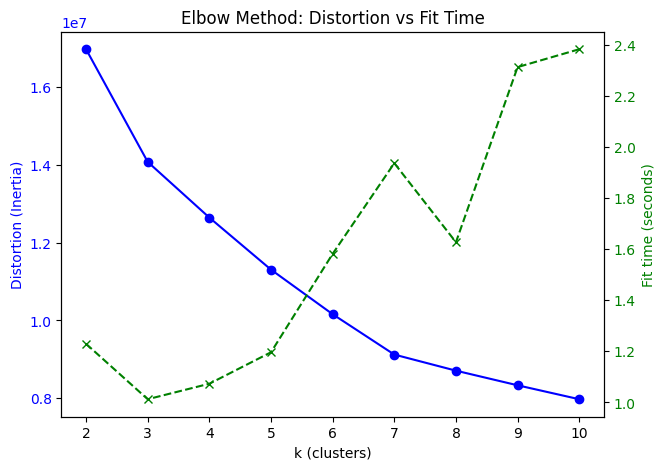

In [18]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import time

def plot_elbow_with_time(X, max_k=10):
    distortions = []
    times = []

    for k in range(2, max_k+1):
        start = time.time()
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X)
        end = time.time()

        distortions.append(km.inertia_)
        times.append(end - start)

    fig, ax1 = plt.subplots(figsize=(7,5))

    # Plot distortion (blue line, left axis)
    ax1.plot(range(2, max_k+1), distortions, marker='o', color='b')
    ax1.set_xlabel("k (clusters)")
    ax1.set_ylabel("Distortion (Inertia)", color='b')
    ax1.tick_params(axis='y', labelcolor='b')

    # Plot fit time (green dashed line, right axis)
    ax2 = ax1.twinx()
    ax2.plot(range(2, max_k+1), times, marker='x', linestyle='--', color='g')
    ax2.set_ylabel("Fit time (seconds)", color='g')
    ax2.tick_params(axis='y', labelcolor='g')

    plt.title("Elbow Method: Distortion vs Fit Time")
    plt.show()
    
X = df_main.select_dtypes(include=['float64','int64'])

plot_elbow_with_time(X, max_k=10)

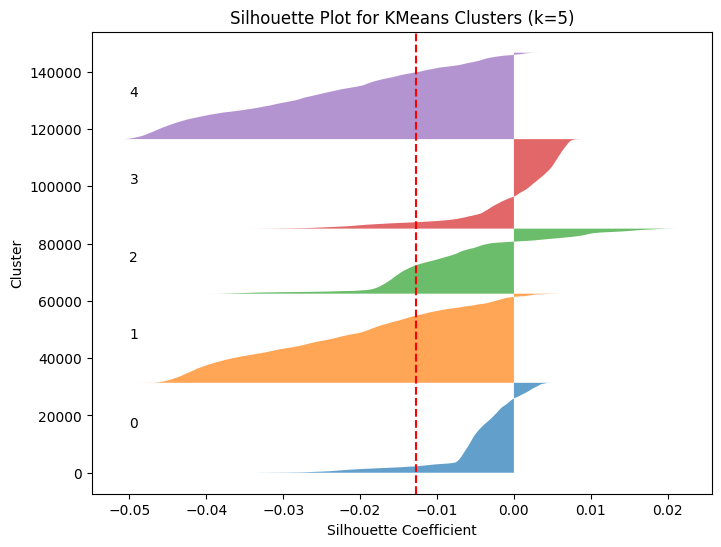

In [17]:
from sklearn.metrics import silhouette_samples
import numpy as np

labels = df_labels["cluster"].values

def plot_silhouette(X, labels):
    sil_vals = silhouette_samples(X, labels)
    k = len(np.unique(labels))
    y_lower = 10
    plt.figure(figsize=(8,6))
    for i in range(k):
        c_sil_vals = sil_vals[labels == i]
        c_sil_vals.sort()
        y_upper = y_lower + len(c_sil_vals)
        plt.fill_betweenx(np.arange(y_lower, y_upper),
                          0, c_sil_vals, alpha=0.7)
        plt.text(-0.05, y_lower + 0.5*len(c_sil_vals), str(i))
        y_lower = y_upper + 10
    plt.axvline(np.mean(sil_vals), color="red", linestyle="--")
    plt.title("Silhouette Plot for KMeans Clusters (k=5)")
    plt.xlabel("Silhouette Coefficient")
    plt.ylabel("Cluster")
    plt.show()

plot_silhouette(X, labels)

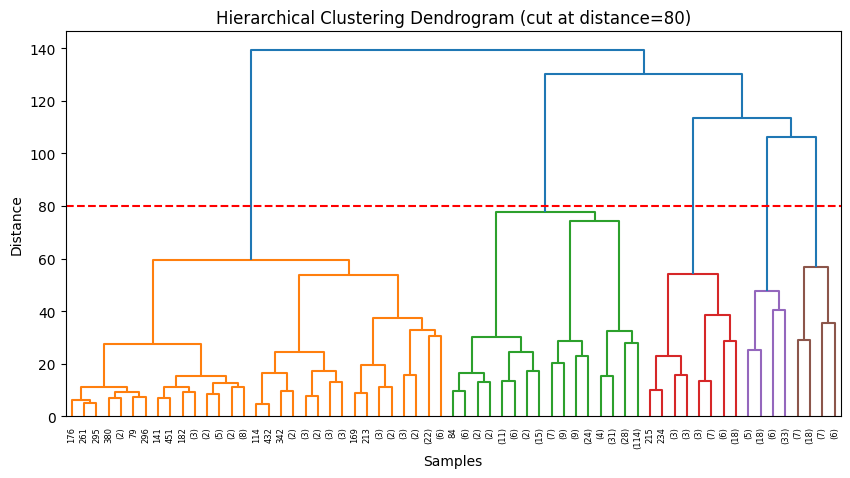

In [20]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X.sample(500, random_state=42), method='ward')

plt.figure(figsize=(10,5))
dendrogram(Z, truncate_mode="level", p=5, color_threshold=80)  # cut at distance 80
plt.axhline(y=80, color='r', linestyle='--')  # red dashed line
plt.title("Hierarchical Clustering Dendrogram (cut at distance=80)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering, DBSCAN

# Take a smaller random sample for clustering
df_sample = df_pca.sample(1000, random_state=42)   # adjust size if needed
X_sample = df_sample[["pc1", "pc2"]].values

# KMeans (already available from labels)
df_sample = df_sample.merge(df_labels, on=["Booking ID","Customer ID"], how="left")

# Agglomerative clustering
agg = AgglomerativeClustering(n_clusters=5)
df_sample["agg_cluster"] = agg.fit_predict(X_sample)

# DBSCAN clustering
db = DBSCAN(eps=1.5, min_samples=10)
df_sample["db_cluster"] = db.fit_predict(X_sample)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18,6))

# KMeans
axes[0].scatter(df_sample["pc1"], df_sample["pc2"], c=df_sample["cluster"], cmap="tab10", s=15)
axes[0].set_title("KMeans (k=5)")

# Agglomerative
axes[1].scatter(df_sample["pc1"], df_sample["pc2"], c=df_sample["agg_cluster"], cmap="tab10", s=15)
axes[1].set_title("Agglomerative Clustering (k=5)")

# DBSCAN
axes[2].scatter(df_sample["pc1"], df_sample["pc2"], c=df_sample["db_cluster"], cmap="tab10", s=15)
axes[2].set_title("DBSCAN")

plt.show()

NameError: name 'df_pca' is not defined

In [2]:
import pandas as pd

# Paths (adjust if needed)
PROJECT_ROOT = "/Users/makabaka/Documents/GitHub/MADS-MS2-Uber-Analysis"
pca_all = f"{PROJECT_ROOT}/unsupervised/pca_2d.csv"
labels_csv = f"{PROJECT_ROOT}/unsupervised/kmeans_k5_labels.csv"

# Load PCA embeddings and KMeans labels
df_pca = pd.read_csv(pca_all)
df_labels = pd.read_csv(labels_csv)

# Merge them together for easier clustering
df_pca = df_pca.merge(df_labels, on=["Booking ID","Customer ID"], how="left")

df_pca.head()

,pc1,pc2,Booking ID,Customer ID,cluster
0,34.674352,-0.516413,"""CNR5884300""","""CID1982111""",0
1,72.945920,-1.061076,"""CNR1326809""","""CID4604802""",0
2,-7.533231,-1.294595,"""CNR8494506""","""CID9202816""",2
3,-41.193555,-58.275377,"""CNR8906825""","""CID2610914""",4
4,-36.233252,-32.593867,"""CNR1950162""","""CID9933542""",4


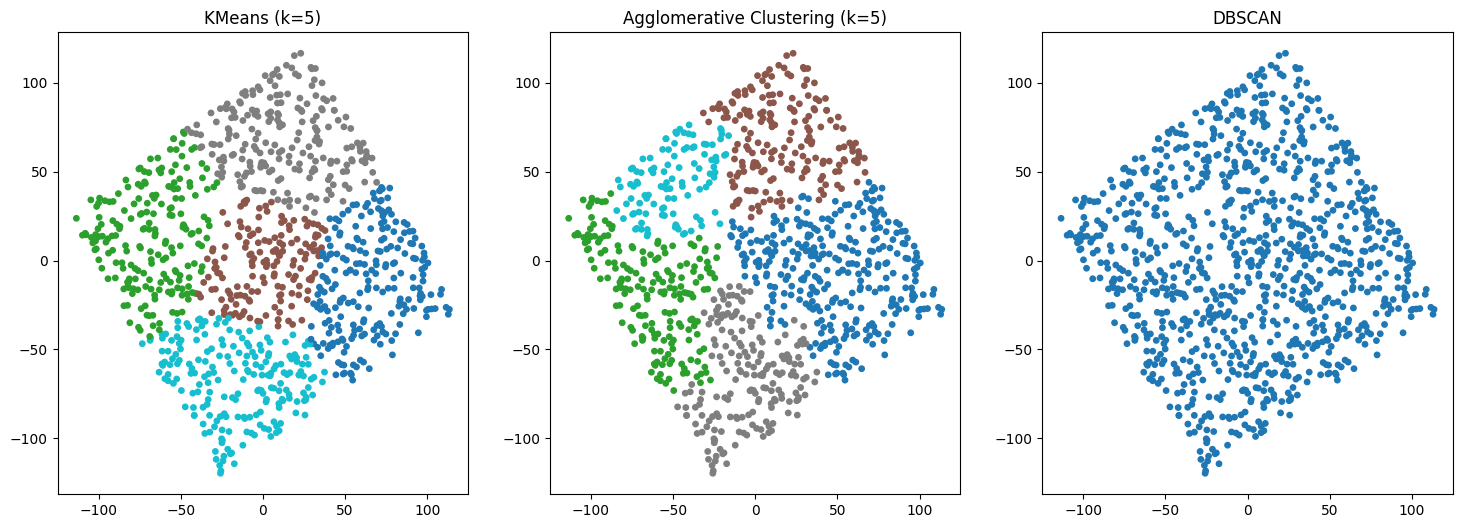

In [3]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN
import matplotlib.pyplot as plt

# Take a smaller random sample for clustering
df_sample = df_pca.sample(1000, random_state=42)
X_sample = df_sample[["pc1", "pc2"]].values

# Agglomerative clustering
agg = AgglomerativeClustering(n_clusters=5)
df_sample["agg_cluster"] = agg.fit_predict(X_sample)

# DBSCAN clustering
db = DBSCAN(eps=1.5, min_samples=10)
df_sample["db_cluster"] = db.fit_predict(X_sample)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18,6))

# KMeans (from labels)
axes[0].scatter(df_sample["pc1"], df_sample["pc2"], c=df_sample["cluster"], cmap="tab10", s=15)
axes[0].set_title("KMeans (k=5)")

# Agglomerative
axes[1].scatter(df_sample["pc1"], df_sample["pc2"], c=df_sample["agg_cluster"], cmap="tab10", s=15)
axes[1].set_title("Agglomerative Clustering (k=5)")

# DBSCAN
axes[2].scatter(df_sample["pc1"], df_sample["pc2"], c=df_sample["db_cluster"], cmap="tab10", s=15)
axes[2].set_title("DBSCAN")

plt.show()

In [10]:
df_main

,Date,Time,booking_datetime,booking_hour,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,...,wind_speed_10m_dropoff_scaled.1,precipitation_log_scaled,precipitation_log_scaled.1,rain_log_scaled,rain_log_scaled.1,snowfall_log_scaled,snowfall_log_scaled.1,precipitation_dropoff_log_scaled,rain_dropoff_log_scaled,snowfall_dropoff_log_scaled
0,2024-03-23,12:29:38,2024-03-23 12:29,2024-03-23 12:00,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,...,1.392857,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1,2024-11-29,18:01:39,2024-11-29 18:01,2024-11-29 18:00,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,...,-1.250000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
2,2024-08-23,8:56:10,2024-08-23 8:56,2024-08-23 8:00,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,...,-0.464286,0.182322,0.182322,0.182322,0.182322,0.0,0.0,0.0,0.0,0.0
3,2024-10-21,17:17:25,2024-10-21 17:17,2024-10-21 17:00,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,...,-0.214286,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
4,2024-09-16,22:08:00,2024-09-16 22:08,2024-09-16 22:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,...,0.017857,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146609,2024-12-02,1:58:43,2024-12-02 1:58,2024-12-02 1:00,"""CNR5613710""",Completed,"""CID4939486""",Premier Sedan,Peeragarhi,Noida Sector 18,...,-0.357143,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
146610,2024-03-07,16:51:55,2024-03-07 16:51,2024-03-07 16:00,"""CNR6069843""",Cancelled by Customer,"""CID6923203""",Go Mini,Mehrauli,Karkarduma,...,0.982143,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
146611,2024-08-05,12:32:58,2024-08-05 12:32,2024-08-05 12:00,"""CNR1820926""",Cancelled by Customer,"""CID3170131""",Premier Sedan,Vaishali,IIT Delhi,...,1.821429,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
146612,2024-01-13,8:55:29,2024-01-13 8:55,2024-01-13 8:00,"""CNR7830403""",Cancelled by Customer,"""CID8832420""",eBike,Khandsa,Paharganj,...,-0.946429,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [8]:
import umap

# Apply UMAP to your numeric features
X = df_main.select_dtypes(include=['float64','int64']).sample(2000, random_state=42)  # sample to speed up
umap_model = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X)

# Add to dataframe
df_umap = pd.DataFrame(X_umap, columns=["umap1", "umap2"])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
